# <p style="background-color:#5A0E24;font-family:newtimeroman;color:#FFF9ED;font-size:90%;text-align:center;border-radius:10px; border: 2px solidrgb(98, 0, 255); padding: 10px;"> Emotion Recognition</p>

## Introduction



Facial Expression Recognition (FER) is the task of detecting a face in an image and classifying its expression into one of a fixed set of emotion categories. This notebook covers the first two stages of the pipeline:



Members:

- عبدالعزيز عادل محمد حامد

- جون هادي نظيم جرجس

- فارس محمد سليمان عبدالمقصود

- ديفيد جورج ادولف عبدالملاك

- خالد ابراهيم احمد عبدالحميد


## Emotion Classes

| Class | Description |
|---|---|
| Anger | Furrowed brows, tightened facial muscles, and a tense expression. |
| Disgust | Wrinkled nose and raised upper lip, often in reaction to something unpleasant. |
| Fear | Widened eyes, raised eyebrows, and an open mouth. |
| Happiness | Smiling expression, raised cheeks, and crinkled eyes. |
| Sadness | Downturned mouth, drooping eyelids, and a downcast expression. |
| Surprise | Raised eyebrows, wide-open eyes, and an open mouth. |
| Neutral | No strong emotional expression. |



**Dataset:** [FER2013 (7 emotions, uniformly augmented)](https://www.kaggle.com/datasets/sayakbera/fer-2013-7-emotions-uniform-dataset/)

## Seeds

In [ ]:
SEED = 42
ENABLE_DETERMINISM = True

import keras
import tensorflow as tf

keras.utils.set_random_seed(SEED)
if ENABLE_DETERMINISM:
    tf.config.experimental.enable_op_determinism()

## Libraries

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import seaborn as sns
import warnings
from pathlib import Path
from PIL import Image
from keras import callbacks, layers, models, optimizers, utils
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

#
<a id='1'></a>

<p style="
    background: linear-gradient(to right, #5C4033, #8B5A2B);
    font-family: 'Times New Roman', serif;
    color: #F5DEB3;
    font-size: 30px;
    text-align: center;
    border-radius: 12px;
    padding: 12px;
    border: 3px solid #D2B48C;
    box-shadow: 2px 2px 10px rgba(210, 180, 140, 0.5);
    font-weight: bold;
    letter-spacing: 1px;
">
    DATA &amp; PREPROCESSING
</p>


## Data Load

In [ ]:
import os
from pathlib import Path
import kagglehub

downloaded_path = kagglehub.dataset_download("sayakbera/fer-2013-7-emotions-uniform-dataset")

DATA_DIR = Path(downloaded_path)

if (DATA_DIR / "FER2013_7emotions_Uniform_Augmented_Dataset").exists():
    DATA_DIR = DATA_DIR / "FER2013_7emotions_Uniform_Augmented_Dataset"

train_dir = DATA_DIR / "train"
val_dir = DATA_DIR / "validation"
test_dir = DATA_DIR / "test"
all_dirs = [train_dir, val_dir, test_dir]

for d in all_dirs:
    print(f"{d.name} classes: {os.listdir(d)}")

print(f"same classes across splits: {os.listdir(train_dir) == os.listdir(val_dir) == os.listdir(test_dir)}")

Using Colab cache for faster access to the 'fer-2013-7-emotions-uniform-dataset' dataset.
train classes: ['Surprise', 'Fear', 'Neutral', 'Sadness', 'Disgust', 'Happiness', 'Anger']
validation classes: ['Surprise', 'Fear', 'Neutral', 'Sadness', 'Disgust', 'Happiness', 'Anger']
test classes: ['Surprise', 'Fear', 'Neutral', 'Sadness', 'Disgust', 'Happiness', 'Anger']
same classes across splits: True


## Analysis & Preprocessing

### Checking and removing corrupted images

In [ ]:
def get_corrupted_images(data_dir: Path) -> list[Path]:
    corrupted = []

    for class_name in os.listdir(data_dir):
        class_dir = data_dir / class_name

        for img_name in os.listdir(class_dir):
            img_path = class_dir / img_name

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                corrupted.append(img_path)

    return corrupted

corrupted_images = []
for d in all_dirs:
    corrupted_images += get_corrupted_images(d)
print(f"[BEFORE DELETION] Corrupted images count: {len(corrupted_images)}")

if len(corrupted_images) == 0:
    print("\nno corrupted images found")
else:
    for img_path in corrupted_images:
        os.remove(img_path)

    corrupted_images = []
    for d in all_dirs:
        corrupted_images += get_corrupted_images(d)
    print(f"[AFTER  DELETION] Corrupted images count: {len(corrupted_images)}")

[BEFORE DELETION] Corrupted images count: 0

no corrupted images found


### Checking formats, color modes & sizes

In [ ]:
def check_formats_modes_sizes(data_dir: Path):
    img_formats, color_modes, sizes = set(), set(), set()

    for class_name in os.listdir(data_dir):
        class_dir = data_dir / class_name
        for img_name in os.listdir(class_dir):
            img_path = class_dir / img_name
            with Image.open(img_path) as img:
                img_formats.add(img_path.suffix)
                color_modes.add(img.mode)
                sizes.add(img.size)

    return img_formats, color_modes, sizes

img_formats, color_modes, sizes = set(), set(), set()
for d in all_dirs:
    f, m, s = check_formats_modes_sizes(d)
    img_formats |= f
    color_modes |= m
    sizes |= s

print(f"Image Formats: {img_formats}")
print(f"Color Modes: {color_modes}")
print(f"Unique Image Sizes: {sizes}")

Image Formats: {'.jpg'}
Color Modes: {'L'}
Unique Image Sizes: {(48, 48)}


### Plotting samples from each class

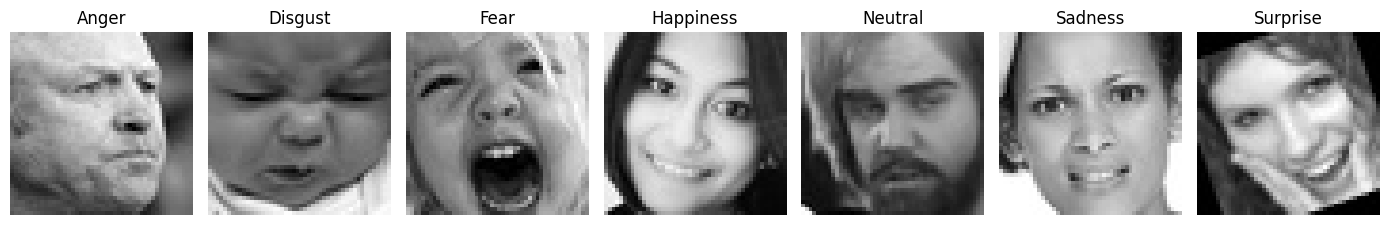

In [ ]:
classes = sorted(os.listdir(train_dir))
plt.figure(figsize=(14, 4))

for i, cls in enumerate(classes):
    class_dir = train_dir / cls
    img_name = random.choice(os.listdir(class_dir))
    img = Image.open(class_dir / img_name)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Counting images per class (class balance)

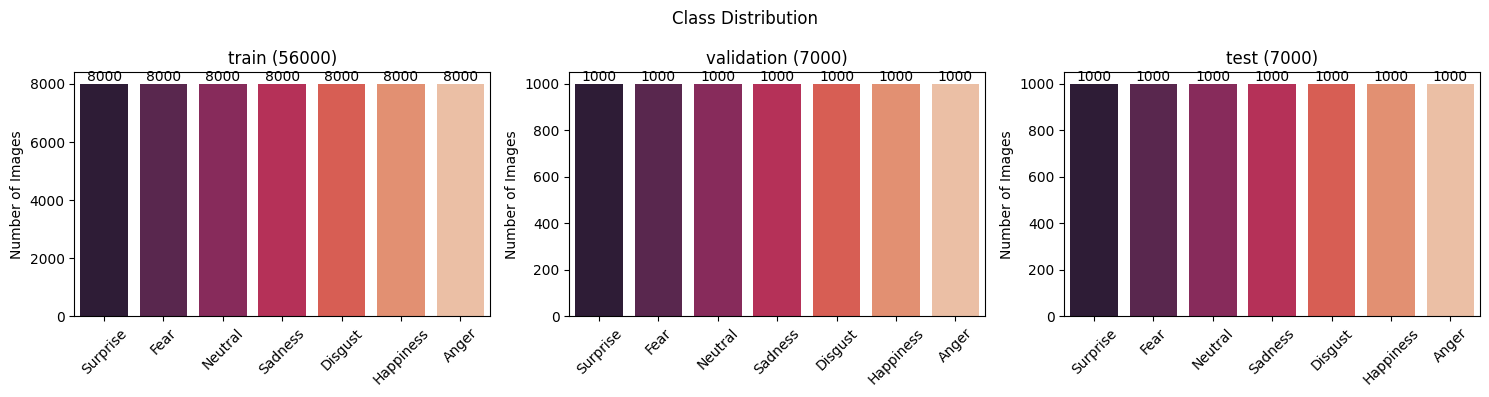

In [ ]:
def count_images(data_dir: Path) -> dict[str, int]:
    return {cls: len(os.listdir(data_dir / cls)) for cls in os.listdir(data_dir)}

plt.figure(figsize=(15, 4))
for i, d in enumerate(all_dirs, start=1):
    class_counts = count_images(d)

    plt.subplot(1, 3, i)
    bars = sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="rocket")
    for container in bars.containers:
        bars.bar_label(container)
    plt.xticks(rotation=45)
    plt.title(f"{d.name} ({sum(class_counts.values())})")
    plt.ylabel("Number of Images")

plt.suptitle("Class Distribution")
plt.tight_layout()
plt.show()

## Split Data

The dataset already ships pre-split into `train` / `validation` / `test` folders, so no manual splitting is required

In [ ]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64

train_ds = utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=True,
    seed=SEED,
)

val_ds = utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False,
)

test_ds = utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False,
)

CLASS_NAMES = train_ds.class_names
CLASS_IDS = list(range(len(CLASS_NAMES)))
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Found 56000 files belonging to 7 classes.
Found 7000 files belonging to 7 classes.
Found 7000 files belonging to 7 classes.
Classes (7): ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']


### Normalizing pixel values

In [ ]:
normalization_layer = layers.Rescaling(1.0 / 255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)

#
<a id='1'></a>

<p style="
    background: linear-gradient(to right, #5C4033, #8B5A2B);
    font-family: 'Times New Roman', serif;
    color: #F5DEB3;
    font-size: 30px;
    text-align: center;
    border-radius: 12px;
    padding: 12px;
    border: 3px solid #D2B48C;
    box-shadow: 2px 2px 10px rgba(210, 180, 140, 0.5);
    font-weight: bold;
    letter-spacing: 1px;
">
    FACE DETECTION &amp; CNN MODEL
</p>


## Face Detection (Haar Cascade)

In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def detect_and_crop_face(image_path, target_size=IMG_SIZE):
    img = cv2.imread(str(image_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        face_img = gray
    else:
        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
        face_img = gray[y:y + h, x:x + w]

    face_img = cv2.resize(face_img, target_size)
    return face_img

## CNN Model

### 1- Model Architecture

In [ ]:
def build_model(input_shape=(48, 48, 1), num_classes=7):
    inputs = layers.Input(shape=input_shape)
    x = inputs

    x = layers.RandomFlip("horizontal", seed=SEED)(x)
    x = layers.RandomRotation(0.1, seed=SEED)(x)
    x = layers.RandomZoom(0.15, seed=SEED)(x)
    x = layers.RandomContrast(0.15, seed=SEED)(x)
    x = layers.RandomTranslation(0.1, 0.1, seed=SEED)(x)

    # CNN
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(512, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.BatchNormalization()(x)

    # FC
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)

model = build_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1), num_classes=NUM_CLASSES)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 48, 48, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 48, 48, 1)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 48, 48, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1, 1, 512)      │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 1,705,095 (6.50 MB)

 Trainable params: 1,703,111 (6.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

### 2- Compile & Callbacks

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_path = Path("emotion_cnn.keras")
training_callbacks = [
    callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    callbacks.ModelCheckpoint(model_path, monitor="val_accuracy", mode="max", save_best_only=True),
]

### 3- Model Fitting

In [ ]:
EPOCHS = 60

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=training_callbacks,
)

Epoch 1/60
875/875 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.2208 - loss: 1.9995 - val_accuracy: 0.2971 - val_loss: 1.7864 - learning_rate: 3.0000e-04
Epoch 2/60
875/875 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.3152 - loss: 1.7496 - val_accuracy: 0.3463 - val_loss: 1.7402 - learning_rate: 3.0000e-04
Epoch 3/60
875/875 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.3936 - loss: 1.5806 - val_accuracy: 0.4293 - val_loss: 1.4829 - learning_rate: 3.0000e-04
Epoch 4/60
875/875 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.4437 - loss: 1.4589 - val_accuracy: 0.4470 - val_loss: 1.4642 - learning_rate: 3.0000e-04
Epoch 5/60
875/875 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.4780 - loss: 1.3693 - val_accuracy: 0.4817 - val_loss: 1.3863 - learning_rate: 3.0000e-04
Epoch 6/60
875/875 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.5070 - loss: 1.2980 - val_accuracy: 0.4814 - val_loss: 1.3876 - learning_rate: 3.0000e-04
Epoch 7/60
875/875 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/ste

### 4- Plotting Results

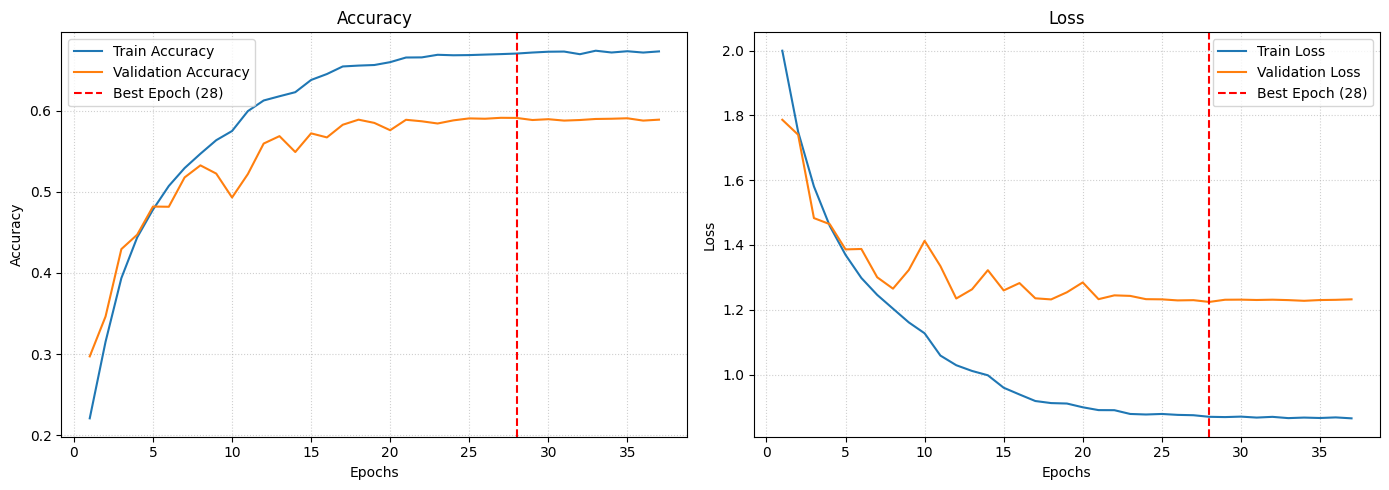

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

best_epoch = np.argmin(history.history['val_loss']) + 1
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Saving Model

Save the trained model + the face detector helper so they can be loaded independently for evaluation and the application: `detect_and_crop_face() → normalize → model.predict()`.

In [ ]:
model.save("emotion_cnn.keras")

print("Model saved to emotion_cnn.keras")
print("CLASS_NAMES (index order used by the model):", CLASS_NAMES)

Model saved to emotion_cnn.keras
CLASS_NAMES (index order used by the model): ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']


In [ ]:
from tensorflow.keras.models import load_model


loaded_model = load_model("emotion_cnn.keras")

#
<a id='1'></a>

<p style="
    background: linear-gradient(to right, #5C4033, #8B5A2B);
    font-family: 'Times New Roman', serif;
    color: #F5DEB3;
    font-size: 30px;
    text-align: center;
    border-radius: 12px;
    padding: 12px;
    border: 3px solid #D2B48C;
    box-shadow: 2px 2px 10px rgba(210, 180, 140, 0.5);
    font-weight: bold;
    letter-spacing: 1px;
">
    EVALUATION
</p>


### Getting predictions on the test set

In [ ]:
y_true, y_pred, y_prob = [], [], []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

### Accuracy

In [ ]:
test_loss, test_acc = loaded_model.evaluate(test_ds, verbose=0)
print(f"Overall Test Accuracy: {(test_acc*100):.2f}%")
print(f"Overall Test Loss:     {(test_loss):.2f}")

Overall Test Accuracy: 60.71%
Overall Test Loss:     1.13


### Precision / Recall / F1-score

In [ ]:
report_text = classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)
print(report_text)

              precision    recall  f1-score   support

       Anger       0.52      0.54      0.53      1000
     Disgust       0.87      0.69      0.77      1000
        Fear       0.44      0.41      0.43      1000
   Happiness       0.77      0.82      0.79      1000
     Neutral       0.53      0.63      0.57      1000
     Sadness       0.44      0.45      0.44      1000
    Surprise       0.73      0.72      0.72      1000

    accuracy                           0.61      7000
   macro avg       0.62      0.61      0.61      7000
weighted avg       0.62      0.61      0.61      7000



### Confusion Matrix

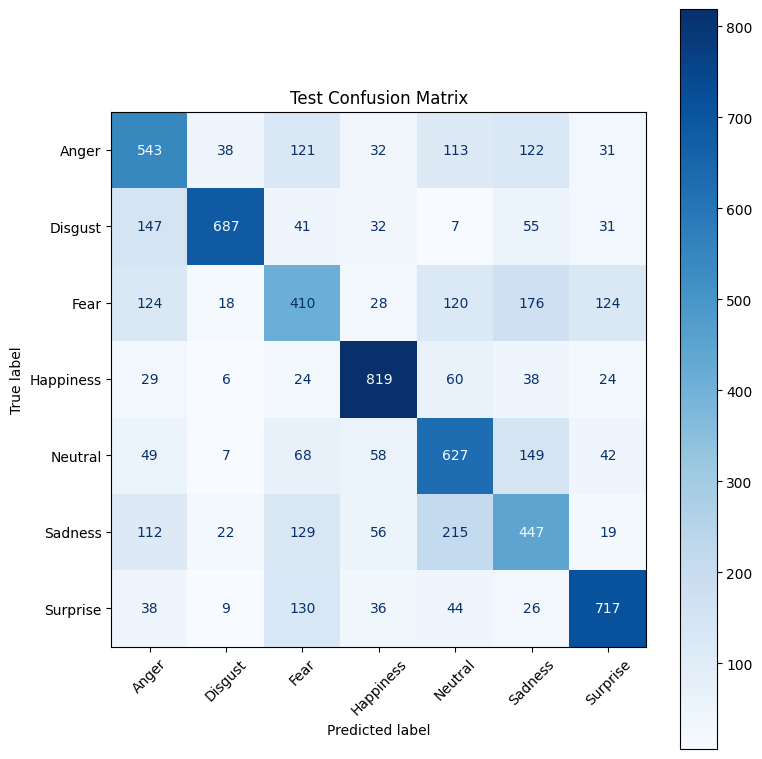

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=CLASS_IDS)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.show()

### Per-Class Performance Breakdown

In [ ]:
report_dict = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES, zero_division=0, output_dict=True)

per_class_df = pd.DataFrame(report_dict).T.loc[CLASS_NAMES, ["precision", "recall", "f1-score", "support"]]
per_class_df = per_class_df.sort_values("f1-score")
per_class_df

,precision,recall,f1-score,support
Fear,0.444204,0.410,0.426417,1000.0
Sadness,0.441264,0.447,0.444113,1000.0
Anger,0.521113,0.543,0.531832,1000.0
Neutral,0.528668,0.627,0.573651,1000.0
Surprise,0.725709,0.717,0.721328,1000.0
Disgust,0.872935,0.687,0.768886,1000.0
Happiness,0.771913,0.819,0.794760,1000.0


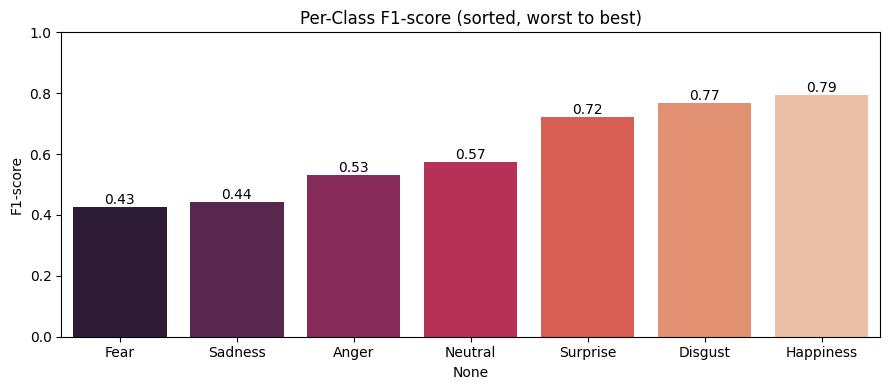

In [ ]:
plt.figure(figsize=(9, 4))
bars = sns.barplot(x=per_class_df.index, y=per_class_df["f1-score"], palette="rocket")
for container in bars.containers:
    bars.bar_label(container, fmt="%.2f")
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.title("Per-Class F1-score (sorted, worst to best)")
plt.tight_layout()
plt.show()